# Data preparation

In [ ]:
# packages
import pandas as pd
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

In [ ]:
!pip install lifelines
from lifelines import CoxPHFitter

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 9.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=548e15d80cc7b669b3bd588b92cc775aaf93b3c3fd7e5029bfdbb759e4df1a42
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
# datasets

# import projects with SG scores
url_full = "https://github.com/Niiingleiii/masterthesis/raw/main/full_list_107.xlsx"
response = requests.get(url_full)
df = pd.read_excel(BytesIO(response.content))

# import transaction information
url_trans = "https://github.com/Niiingleiii/masterthesis/raw/main/carbonplan_merged_forest_verra.xlsx"
response_trans = requests.get(url_trans)
df_trans = pd.read_excel(BytesIO(response_trans.content))

In [ ]:
# clean up datasets

# clean up df_trans
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date']).dt.date
columns_to_drop = [
    'first_issuance_at', 'first_retirement_at', 'is_compliance', 'total_issued','listed_at', 'name', 'project_type', 'project_type_source', 'project_url', 'proponent', 'protocol', 'registry', 'total_retired', 'status', 'category', 'cleaned_id']
df_trans = df_trans.drop(columns=columns_to_drop, errors='ignore')

# create a new copy -- df_trans's subset based on the the project id from df
df_trans_matched = df_trans[df_trans['project_id'].isin(df['project_id'])]
df_trans_matched.shape



(78091, 11)

In [ ]:
# Define vintage_date as July 1 of the vintage year
df_trans_matched['vintage'] = df_trans_matched['vintage'].astype(int)
df_trans_matched['vintage_date'] = pd.to_datetime(df_trans_matched['vintage'].astype(str) + '-07-01')

# Compute delay in years
df_trans_matched['transaction_date'] = pd.to_datetime(df_trans_matched['transaction_date'])
df_trans_matched['delay_years'] = (
    df_trans_matched['transaction_date'] - df_trans_matched['vintage_date']
).dt.days / 365.25

df_trans_matched.head()

/tmp/ipython-input-3340262030.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trans_matched['vintage'] = df_trans_matched['vintage'].astype(int)
/tmp/ipython-input-3340262030.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trans_matched['vintage_date'] = pd.to_datetime(df_trans_matched['vintage'].astype(str) + '-07-01')
/tmp/ipython-input-3340262030.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

,project_id,quantity,retirement_account,retirement_beneficiary,retirement_beneficiary_harmonized,retirement_note,retirement_reason,transaction_date,transaction_type,vintage,country,vintage_date,delay_years
0,VCS1015,2648,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2008,India,2008-07-01,14.989733
1,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2009,India,2009-07-01,13.990418
2,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2010,India,2010-07-01,12.991102
3,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2011,India,2011-07-01,11.991786
4,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2012,India,2012-07-01,10.989733


In [ ]:
# find project IDs that have never retired any credits
no_retire_projects = df[df['retired'].isna() | (df['retired'] == 0)]['project_id'].unique()

# exclude them from df
df = df[~df['project_id'].isin(no_retire_projects)].copy()

# exclude them from df_trans_matched
df_trans_matched = df_trans_matched[~df_trans_matched['project_id'].isin(no_retire_projects)].copy()

print(f"delete {len(no_retire_projects)} project(s) without retirement")


删除了 2 个没有 retirement 的项目


## Build variables of interest

In [ ]:
# Define vintage_date as July 1 of the vintage year
df_trans_matched['vintage'] = df_trans_matched['vintage'].astype(int)
df_trans_matched['vintage_date'] = pd.to_datetime(df_trans_matched['vintage'].astype(str) + '-07-01')

# Compute delay in years
df_trans_matched['transaction_date'] = pd.to_datetime(df_trans_matched['transaction_date'])
df_trans_matched['delay_years'] = (
    df_trans_matched['transaction_date'] - df_trans_matched['vintage_date']
).dt.days / 365.25

# Split issuance and retirement
df_issuance = df_trans_matched[df_trans_matched['transaction_type'] == 'issuance'].copy()
df_retirement = df_trans_matched[df_trans_matched['transaction_type'] == 'retirement'].copy()

# --- 1. Issuance lag ---
issuance_grouped = df_issuance.groupby('project_id').agg(
    weighted_delay_sum=('delay_years', lambda g: (g * df_issuance.loc[g.index, 'quantity']).sum()),
    total_quantity=('quantity', 'sum')
)
issuance_grouped['issuance_lag_years'] = issuance_grouped['weighted_delay_sum'] / issuance_grouped['total_quantity']
issuance_lag = issuance_grouped[['issuance_lag_years']].reset_index()

# --- 2. Retirement age ---
retirement_grouped = df_retirement.groupby('project_id').agg(
    weighted_delay_sum=('delay_years', lambda g: (g * df_retirement.loc[g.index, 'quantity']).sum()),
    total_quantity=('quantity', 'sum')
)
retirement_grouped['retirement_age_years'] = retirement_grouped['weighted_delay_sum'] / retirement_grouped['total_quantity']
retirement_age = retirement_grouped[['retirement_age_years']].reset_index()


In [ ]:
# 3. trading life -- issuance date map
# Count unique issuance dates per (project_id, vintage)
issuance_counts = (
    df_issuance.groupby(['project_id', 'vintage'])['transaction_date']
    .nunique()
    .reset_index(name='n_dates')
)

# Merge back to tag each row
df_issuance = df_issuance.merge(issuance_counts, on=['project_id', 'vintage'], how='left')

# Separate the two cases
# case 1: this vintage date only linked to one issuance date
issuance_single = (
    df_issuance[df_issuance['n_dates'] == 1]
    .groupby(['project_id', 'vintage'])['transaction_date']
    .first()
    .reset_index()
    .rename(columns={'transaction_date': 'early_date'})
)
issuance_single['late_date'] = issuance_single['early_date']
issuance_single['weighted_date'] = issuance_single['early_date']

# case 2: this vintage date linked to two issuance dates
def _weighted_dt(gr):
    return np.average(gr['transaction_date'].astype('int64'), weights=gr['quantity'])

tmp = df_issuance[df_issuance['n_dates'] > 1].copy()
issuance_multi_weighted = (
    tmp.groupby(['project_id', 'vintage'])
       .apply(_weighted_dt)
       .reset_index(name='weighted_date')
)
issuance_multi_weighted['weighted_date'] = pd.to_datetime(
    issuance_multi_weighted['weighted_date'].astype('int64')
)
# distinguish the eariler date and later date
issuance_multi_bounds = (
    tmp.groupby(['project_id', 'vintage'])['transaction_date']
       .agg(early_date='min', late_date='max')
       .reset_index()
)
issuance_multi = issuance_multi_bounds.merge(
    issuance_multi_weighted, on=['project_id', 'vintage'], how='left'
)

# construct the issuance_map (include early/late/weighted date)
issuance_map = pd.concat([issuance_single, issuance_multi], ignore_index=True)

/tmp/ipython-input-1614822072.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_weighted_dt)


In [ ]:
# Merge the issuance date for that vintage
df_retirement = df_retirement.merge(
    issuance_map, on=['project_id', 'vintage'], how='left'
)

# find issuance date by retirement date
ret_dt = df_retirement['transaction_date']
early = df_retirement['early_date']
late = df_retirement['late_date']
weighted = df_retirement['weighted_date']
# if the retirement date is in between the corresponding two issuance date, take the earlier date;
# if the retirement date is later than the corresponding two issuance date, take the weighter date
df_retirement['issuance_date_for_vintage'] = np.where(
    ret_dt <= late,
    early,
    weighted
)

# Compute trading life in years (per transaction)
df_retirement['trading_life_years'] = (
    (df_retirement['transaction_date'] - df_retirement['issuance_date_for_vintage'])
    / pd.Timedelta(days=365.25)
)

# Aggregate to project level (value-weighted)
project_trading_life = df_retirement.groupby('project_id').apply(
    lambda g: (g['trading_life_years'] * g['quantity']).sum() / g['quantity'].sum()
).reset_index(name='trading_life_years')


/tmp/ipython-input-826803875.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  project_trading_life = df_retirement.groupby('project_id').apply(


In [ ]:
project_trading_life.head()

,project_id,trading_life_years
0,VCS1015,0.195787
1,VCS1067,3.687801
2,VCS1085,1.254047
3,VCS1094,4.267949
4,VCS1112,1.900040


In [ ]:
df_issuance['vintage'] = df_issuance['vintage'].astype(int)
df_issuance['vintage_date'] = pd.to_datetime(df_issuance['vintage'].astype(str) + "-07-01")

def weighted_datetime_vintage(group):
    weights = group['quantity']
    dates = group['vintage_date'].astype('int64')  # convert to nanoseconds
    return np.average(dates, weights=weights)

weighted_vintage_dates = df_issuance.groupby('project_id').apply(weighted_datetime_vintage)

issuance_weighted_vintage = weighted_vintage_dates.reset_index(name='weighted_vintage_date')
issuance_weighted_vintage['weighted_vintage_date'] = pd.to_datetime(
    issuance_weighted_vintage['weighted_vintage_date'].astype('int64')
)

if 'project_id' not in issuance_weighted_vintage.columns:
    issuance_weighted_vintage = issuance_weighted_vintage.reset_index()

/tmp/ipython-input-1710568331.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_vintage_dates = df_issuance.groupby('project_id').apply(weighted_datetime_vintage)


In [ ]:
# Merge issuance lag
df = df.merge(issuance_lag, on='project_id', how='left')

# Merge retirement age
df = df.merge(retirement_age, on='project_id', how='left')

# Merge trading life
df = df.merge(project_trading_life, on='project_id', how='left')

# Merge weighted vintage date
df = df.merge(
    issuance_weighted_vintage[['project_id', 'weighted_vintage_date']],
    on='project_id', how='left'
)


In [ ]:
df.columns

Index(['country', 'first_issuance_at', 'first_retirement_at', 'issued',
       'project_id', 'project_type', 'proponent', 'retired', 'ghg',
       'sdg_rating', 'sdg', 'gender', 'labor', 'biodiversity', 'resource',
       'pollution', 'iplc', 'cultural', 'hss', 'benefit', 'land', 'assessment',
       'stakeholder', 'mrv', 'grievance', 'total', 'issuance_lag_years',
       'retirement_age_years', 'trading_life_years', 'weighted_vintage_date'],
      dtype='object')

In [ ]:
df_trans_matched.columns

Index(['project_id', 'quantity', 'retirement_account',
       'retirement_beneficiary', 'retirement_beneficiary_harmonized',
       'retirement_note', 'retirement_reason', 'transaction_date',
       'transaction_type', 'vintage', 'country', 'vintage_date',
       'delay_years'],
      dtype='object')

In [ ]:
# 1. Add issuance and retirement lag from delay_years
df_trans_matched['issuance_lag_years'] = np.nan
df_trans_matched.loc[df_trans_matched['transaction_type'] == 'issuance', 'issuance_lag_years'] = \
    df_trans_matched['delay_years']

df_trans_matched['retirement_age_years'] = np.nan
df_trans_matched.loc[df_trans_matched['transaction_type'] == 'retirement', 'retirement_age_years'] = \
    df_trans_matched['delay_years']

# 2. Merge issuance_date_for_vintage if not already
df_trans_matched = df_trans_matched.merge(
    issuance_map, on=['project_id', 'vintage'], how='left'
)

# 3. Add trading life years for retirement
# 0)
im = issuance_map.rename(columns={
    'early_date': 'im_early',
    'late_date': 'im_late',
    'weighted_date': 'im_weighted'
})

# 1) Merge
df_trans_matched.drop(columns=[
    'early_date','late_date','weighted_date','issuance_date_for_vintage'
], errors='ignore', inplace=True)

df_trans_matched['vintage'] = df_trans_matched['vintage'].astype(int)
im['vintage'] = im['vintage'].astype(int)

df_trans_matched = df_trans_matched.merge(
    im[['project_id','vintage','im_early','im_late','im_weighted']],
    on=['project_id','vintage'],
    how='left',
    validate='many_to_one'
)

# 2) assign issuance date for retirement → issuance_date_for_vintage
ret_mask = df_trans_matched['transaction_type'].eq('retirement')
df_trans_matched.loc[ret_mask, 'issuance_date_for_vintage'] = np.where(
    df_trans_matched.loc[ret_mask, 'transaction_date'] <= df_trans_matched.loc[ret_mask, 'im_late'],
    df_trans_matched.loc[ret_mask, 'im_early'],
    df_trans_matched.loc[ret_mask, 'im_weighted']
)

# 3) trading_life_years
df_trans_matched['trading_life_years'] = np.nan
df_trans_matched.loc[ret_mask, 'trading_life_years'] = (
    (df_trans_matched.loc[ret_mask, 'transaction_date'] -
     df_trans_matched.loc[ret_mask, 'issuance_date_for_vintage']) / pd.Timedelta(days=365.25)
)

# drop the helper columns
df_trans_matched.drop(columns=['im_early','im_late','im_weighted'], inplace=True)


In [ ]:
df_trans_matched.info()
df_trans_matched.head(30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78083 entries, 0 to 78082
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   project_id                         78083 non-null  object        
 1   quantity                           78083 non-null  int64         
 2   retirement_account                 0 non-null      float64       
 3   retirement_beneficiary             35072 non-null  object        
 4   retirement_beneficiary_harmonized  12317 non-null  object        
 5   retirement_note                    60775 non-null  object        
 6   retirement_reason                  62353 non-null  object        
 7   transaction_date                   78083 non-null  datetime64[ns]
 8   transaction_type                   78083 non-null  object        
 9   vintage                            78083 non-null  int64         
 10  country                           

,project_id,quantity,retirement_account,retirement_beneficiary,retirement_beneficiary_harmonized,retirement_note,retirement_reason,transaction_date,transaction_type,vintage,country,vintage_date,delay_years,issuance_lag_years,retirement_age_years,issuance_date_for_vintage,trading_life_years
0,VCS1015,2648,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2008,India,2008-07-01,14.989733,14.989733,NaN,NaT,NaN
1,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2009,India,2009-07-01,13.990418,13.990418,NaN,NaT,NaN
2,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2010,India,2010-07-01,12.991102,12.991102,NaN,NaT,NaN
3,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2011,India,2011-07-01,11.991786,11.991786,NaN,NaT,NaN
4,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2012,India,2012-07-01,10.989733,10.989733,NaN,NaT,NaN
5,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2013,India,2013-07-01,9.990418,9.990418,NaN,NaT,NaN
6,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2024-01-19,issuance,2020,India,2020-07-01,3.550992,3.550992,NaN,NaT,NaN
7,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2024-02-02,issuance,2014,India,2014-07-01,9.590691,9.590691,NaN,NaT,NaN
8,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2025-05-08,issuance,2015,India,2015-07-01,9.853525,9.853525,NaN,NaT,NaN
9,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2025-05-08,issuance,2016,India,2016-07-01,8.851472,8.851472,NaN,NaT,NaN


retirement_age_years min: 0.32854209445585214 max: 21.765913757700204 skew: 2.134788266168794


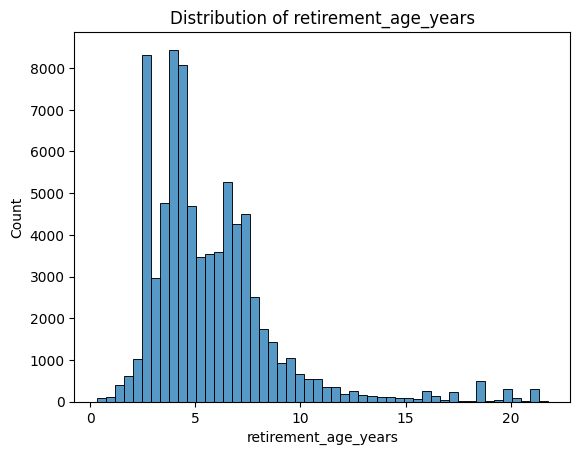

trading_life_years min: 0.0 max: 13.163586584531142 skew: 1.2052710558159079


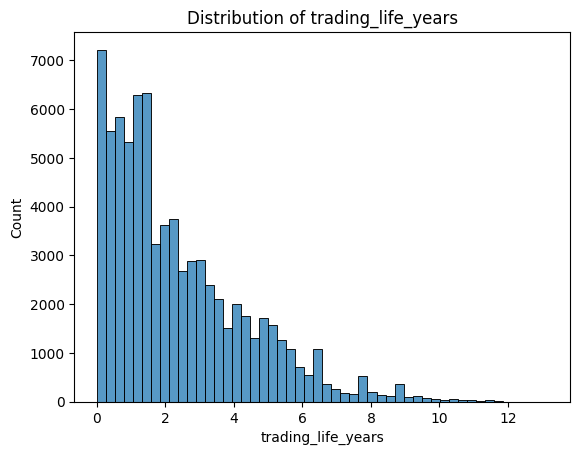

issuance_lag_years min: 0.07392197125256673 max: 21.39630390143737 skew: 1.873636417687289


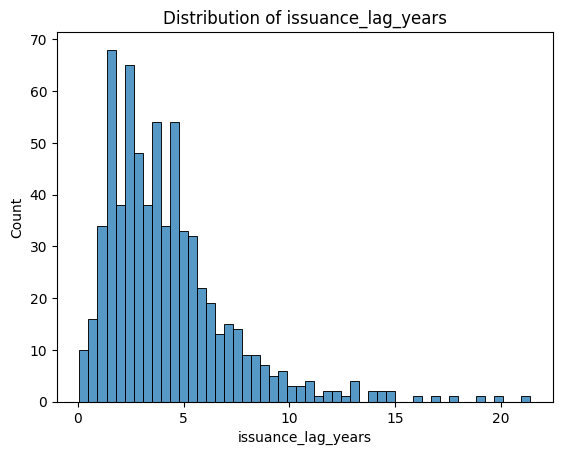

In [ ]:
for col in ["retirement_age_years", "trading_life_years", "issuance_lag_years"]:
    print(col, "min:", df_trans_matched[col].min(), "max:", df_trans_matched[col].max(), "skew:", df_trans_matched[col].skew())
    sns.histplot(df_trans_matched[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
# Compute total issuance and retirement quantity per project
issued = df_issuance.groupby('project_id')['quantity'].sum().reset_index(name='total_issued')
retired = df_retirement.groupby('project_id')['quantity'].sum().reset_index(name='total_retired')

# Merge into df
df = df.merge(issued, on='project_id', how='left')
df = df.merge(retired, on='project_id', how='left')

# Calculate retirement ratio
df['retirement_ratio'] = df['total_retired'] / df['total_issued']

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   country                105 non-null    object        
 1   first_issuance_at      105 non-null    datetime64[ns]
 2   first_retirement_at    105 non-null    datetime64[ns]
 3   issued                 105 non-null    int64         
 4   project_id             105 non-null    object        
 5   project_type           105 non-null    object        
 6   proponent              105 non-null    object        
 7   retired                105 non-null    int64         
 8   ghg                    105 non-null    float64       
 9   sdg_rating             105 non-null    object        
 10  sdg                    76 non-null     object        
 11  gender                 105 non-null    int64         
 12  labor                  105 non-null    int64         
 13  biodi

,country,first_issuance_at,first_retirement_at,issued,project_id,project_type,proponent,retired,ghg,sdg_rating,...,mrv,grievance,total,issuance_lag_years,retirement_age_years,trading_life_years,weighted_vintage_date,total_issued,total_retired,retirement_ratio
0,India,2023-06-28,2024-01-19,78003,VCS1015,Afforestation + Reforestation,Indian Farm Forestry Development Co-operative ...,48998,2.0,Not certified,...,2,2,15,9.034592,7.336712,0.195787,2015-05-21 18:41:20.858428416,78003,48998,0.628155
1,Peru,2013-09-25,2013-09-26,4874608,VCS1067,REDD+,AsociaciÃ³n para la InvestigaciÃ³n y Desarroll...,4102490,3.0,3,...,2,2,15,2.443691,6.161015,3.687801,2017-02-11 02:29:48.201389568,4874608,4102490,0.841604
2,Nicaragua,2020-03-25,2020-03-25,263426,VCS1085,Afforestation + Reforestation,"EcoPlanet Bamboo Group, LLC",257060,3.0,Not certified,...,0,2,11,1.543993,2.813496,1.254047,2019-09-20 18:48:35.302210048,263426,257060,0.975834
3,Brazil,2015-02-24,2015-06-18,2071291,VCS1094,REDD+,Multiple Proponents,1817677,3.0,3,...,2,2,19,8.532246,13.055864,4.267949,2008-09-13 09:03:11.958541824,2071291,1817677,0.877558
4,Cambodia,2018-12-17,2019-04-16,27627237,VCS1748,REDD+,"Royal Government of Cambodia (RGC), Ministry o...",6530032,3.0,5,...,2,2,26,2.333014,5.496777,2.630103,2018-06-24 02:44:24.173388032,27627237,6530032,0.236362


retirement_age_years min: 1.5396630501646695 max: 13.055864229971073 skew: 1.3002894652493984


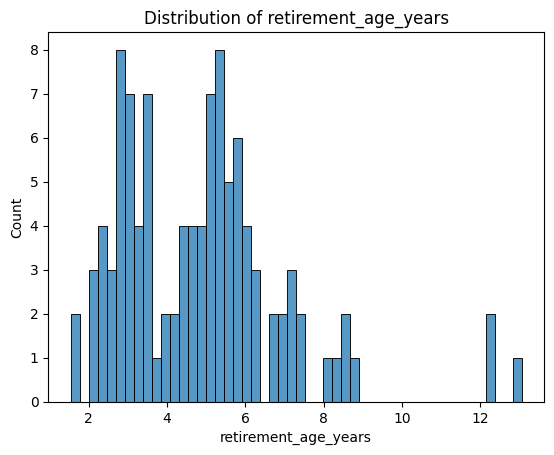

trading_life_years min: 0.0 max: 4.581909531810375 skew: 1.0294288026842706


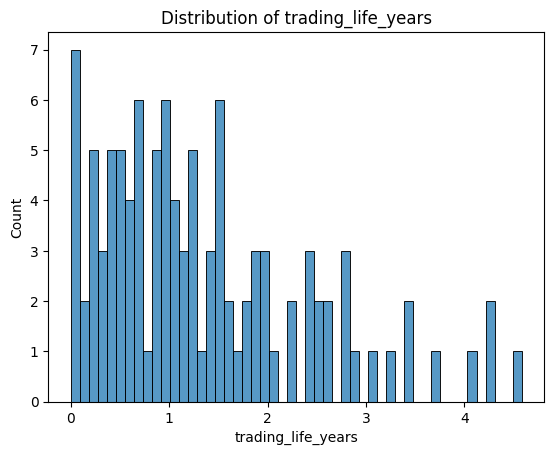

issuance_lag_years min: 0.3121149897330596 max: 11.888996826502263 skew: 1.4494023616418583


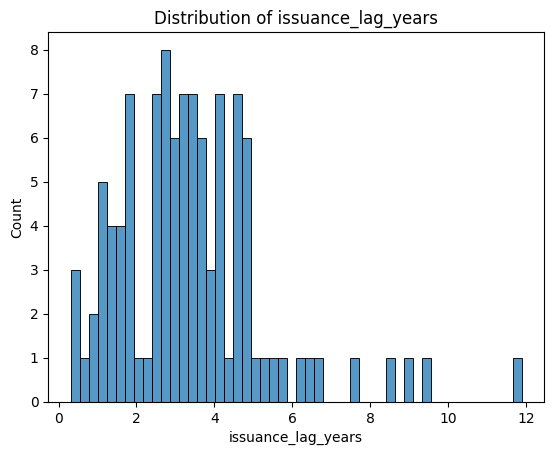

In [ ]:
for col in ["retirement_age_years", "trading_life_years", "issuance_lag_years"]:
    print(col, "min:", df[col].min(), "max:", df[col].max(), "skew:", df[col].skew())
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

### Log Transform

In [ ]:
# set a very small number to avoid log(0)
EPS = 1e-6

# Add log trans weighted avg
df_iss = df_trans_matched[df_trans_matched['transaction_type'] == 'issuance'].copy()
df_ret = df_trans_matched[df_trans_matched['transaction_type'] == 'retirement'].copy()

# E[log(delay_years)]
iss_log_mean = (
    df_iss.assign(_y=np.log(np.clip(df_iss['delay_years'], EPS, None)))
         .groupby('project_id')
         .apply(lambda g: (g['_y'] * g['quantity']).sum() / g['quantity'].sum())
         .reset_index(name='issuance_lag_LOG_mean')
)

# E[log(delay_years)]
ret_age_log_mean = (
    df_ret.assign(_y=np.log(np.clip(df_ret['delay_years'], EPS, None)))
         .groupby('project_id')
         .apply(lambda g: (g['_y'] * g['quantity']).sum() / g['quantity'].sum())
         .reset_index(name='retirement_age_LOG_mean')
)

# df_ret['trading_life_years']
tl_log_mean = (
    df_ret.assign(_y=np.log(np.clip(df_ret['trading_life_years'], EPS, None)))
         .groupby('project_id')
         .apply(lambda g: (g['_y'] * g['quantity']).sum() / g['quantity'].sum())
         .reset_index(name='trading_life_LOG_mean')
)

# merge, project level df
df = df.merge(iss_log_mean, on='project_id', how='left')
df = df.merge(ret_age_log_mean, on='project_id', how='left')
df = df.merge(tl_log_mean, on='project_id', how='left')


/tmp/ipython-input-2299764783.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['_y'] * g['quantity']).sum() / g['quantity'].sum())
/tmp/ipython-input-2299764783.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['_y'] * g['quantity']).sum() / g['quantity'].sum())
/tmp/ipython-input-2299764783.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

In [ ]:
# non-negative → log(clip)
df_trans_matched['issuance_lag_LOG'] = np.log(
    np.clip(df_trans_matched['issuance_lag_years'], EPS, None)
)

df_trans_matched['retirement_age_LOG'] = np.log(
    np.clip(df_trans_matched['retirement_age_years'], EPS, None)
)

df_trans_matched['trading_life_LOG'] = np.log(
    np.clip(df_trans_matched['trading_life_years'], EPS, None)
)

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   country                  105 non-null    object        
 1   first_issuance_at        105 non-null    datetime64[ns]
 2   first_retirement_at      105 non-null    datetime64[ns]
 3   issued                   105 non-null    int64         
 4   project_id               105 non-null    object        
 5   project_type             105 non-null    object        
 6   proponent                105 non-null    object        
 7   retired                  105 non-null    int64         
 8   ghg                      105 non-null    float64       
 9   sdg_rating               105 non-null    object        
 10  sdg                      76 non-null     object        
 11  gender                   105 non-null    int64         
 12  labor                    105 non-nul

,country,first_issuance_at,first_retirement_at,issued,project_id,project_type,proponent,retired,ghg,sdg_rating,...,issuance_lag_years,retirement_age_years,trading_life_years,weighted_vintage_date,total_issued,total_retired,retirement_ratio,issuance_lag_LOG_mean,retirement_age_LOG_mean,trading_life_LOG_mean
0,India,2023-06-28,2024-01-19,78003,VCS1015,Afforestation + Reforestation,Indian Farm Forestry Development Co-operative ...,48998,2.0,Not certified,...,9.034592,7.336712,0.195787,2015-05-21 18:41:20.858428416,78003,48998,0.628155,2.114960,1.920010,-10.884890
1,Peru,2013-09-25,2013-09-26,4874608,VCS1067,REDD+,AsociaciÃ³n para la InvestigaciÃ³n y Desarroll...,4102490,3.0,3,...,2.443691,6.161015,3.687801,2017-02-11 02:29:48.201389568,4874608,4102490,0.841604,0.824360,1.757055,0.993254
2,Nicaragua,2020-03-25,2020-03-25,263426,VCS1085,Afforestation + Reforestation,"EcoPlanet Bamboo Group, LLC",257060,3.0,Not certified,...,1.543993,2.813496,1.254047,2019-09-20 18:48:35.302210048,263426,257060,0.975834,0.153772,0.923032,-1.696821
3,Brazil,2015-02-24,2015-06-18,2071291,VCS1094,REDD+,Multiple Proponents,1817677,3.0,3,...,8.532246,13.055864,4.267949,2008-09-13 09:03:11.958541824,2071291,1817677,0.877558,2.017711,2.529067,-0.025557
4,Cambodia,2018-12-17,2019-04-16,27627237,VCS1748,REDD+,"Royal Government of Cambodia (RGC), Ministry o...",6530032,3.0,5,...,2.333014,5.496777,2.630103,2018-06-24 02:44:24.173388032,27627237,6530032,0.236362,0.778831,1.650628,0.761707


In [ ]:
df[df['trading_life_years'] < 0]

,country,first_issuance_at,first_retirement_at,issued,project_id,project_type,proponent,retired,ghg,sdg_rating,...,issuance_lag_years,retirement_age_years,trading_life_years,weighted_vintage_date,total_issued,total_retired,retirement_ratio,issuance_lag_LOG_mean,retirement_age_LOG_mean,trading_life_LOG_mean


issuance_lag_LOG_mean min: -1.1643836022363134 max: 2.369345050431037 skew: -0.9498066358156279


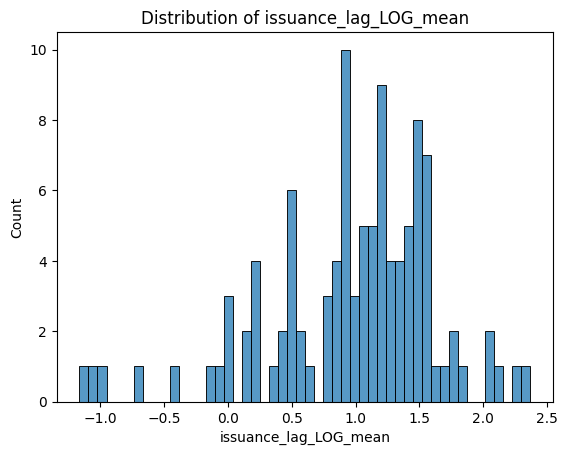

retirement_age_LOG_mean min: 0.22534974005348657 max: 2.5290670178224914 skew: -0.18717187443228525


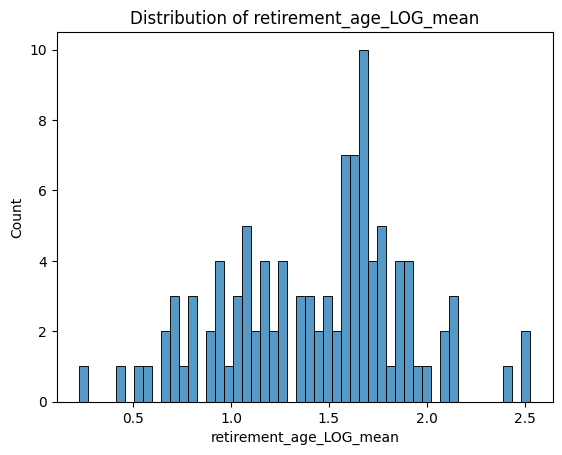

trading_life_LOG_mean min: -13.815510557964274 max: 1.457147389674774 skew: -1.526875992337866


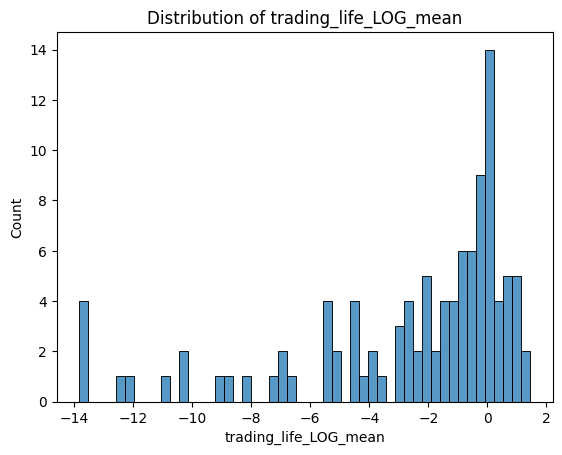

In [ ]:
for col in ["issuance_lag_LOG_mean", "retirement_age_LOG_mean", "trading_life_LOG_mean"]:
    print(col, "min:", df[col].min(), "max:", df[col].max(), "skew:", df[col].skew())
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
df_trans_matched.info()
df_trans_matched.head(30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78083 entries, 0 to 78082
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   project_id                         78083 non-null  object        
 1   quantity                           78083 non-null  int64         
 2   retirement_account                 0 non-null      float64       
 3   retirement_beneficiary             35072 non-null  object        
 4   retirement_beneficiary_harmonized  12317 non-null  object        
 5   retirement_note                    60775 non-null  object        
 6   retirement_reason                  62353 non-null  object        
 7   transaction_date                   78083 non-null  datetime64[ns]
 8   transaction_type                   78083 non-null  object        
 9   vintage                            78083 non-null  int64         
 10  country                           

,project_id,quantity,retirement_account,retirement_beneficiary,retirement_beneficiary_harmonized,retirement_note,retirement_reason,transaction_date,transaction_type,vintage,country,vintage_date,delay_years,issuance_lag_years,retirement_age_years,issuance_date_for_vintage,trading_life_years,issuance_lag_LOG,retirement_age_LOG,trading_life_LOG
0,VCS1015,2648,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2008,India,2008-07-01,14.989733,14.989733,NaN,NaT,NaN,2.707366,NaN,NaN
1,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2009,India,2009-07-01,13.990418,13.990418,NaN,NaT,NaN,2.638373,NaN,NaN
2,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2010,India,2010-07-01,12.991102,12.991102,NaN,NaT,NaN,2.564265,NaN,NaN
3,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2011,India,2011-07-01,11.991786,11.991786,NaN,NaT,NaN,2.484222,NaN,NaN
4,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2012,India,2012-07-01,10.989733,10.989733,NaN,NaT,NaN,2.396961,NaN,NaN
5,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2013,India,2013-07-01,9.990418,9.990418,NaN,NaT,NaN,2.301626,NaN,NaN
6,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2024-01-19,issuance,2020,India,2020-07-01,3.550992,3.550992,NaN,NaT,NaN,1.267227,NaN,NaN
7,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2024-02-02,issuance,2014,India,2014-07-01,9.590691,9.590691,NaN,NaT,NaN,2.260793,NaN,NaN
8,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2025-05-08,issuance,2015,India,2015-07-01,9.853525,9.853525,NaN,NaT,NaN,2.287829,NaN,NaN
9,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2025-05-08,issuance,2016,India,2016-07-01,8.851472,8.851472,NaN,NaT,NaN,2.180584,NaN,NaN


issuance_lag_LOG min: -2.6047451846264797 max: 3.063218192224768 skew: -0.6391005694651896


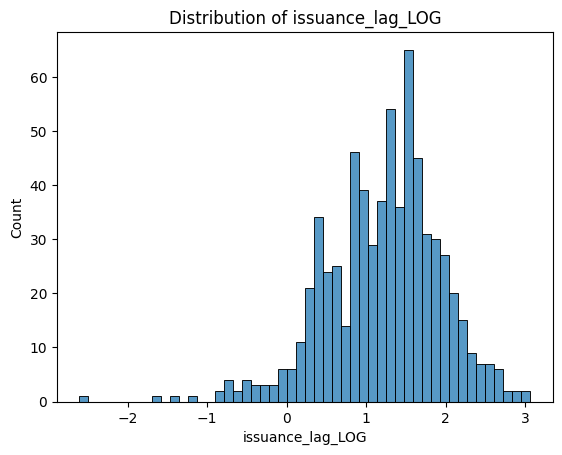

retirement_age_LOG min: -1.1130903078487628 max: 3.0803451570175686 skew: 0.18454857455069226


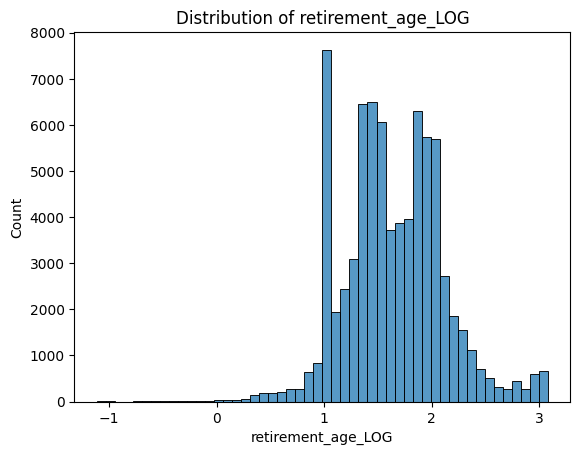

trading_life_LOG min: -13.815510557964274 max: 2.5774544255842344 skew: -4.78470170707164


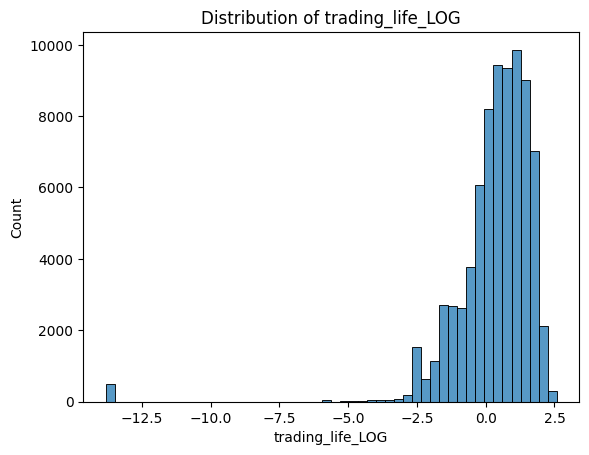

In [ ]:
for col in ["issuance_lag_LOG", "retirement_age_LOG", "trading_life_LOG"]:
    print(col, "min:", df_trans_matched[col].min(), "max:", df_trans_matched[col].max(), "skew:", df_trans_matched[col].skew())
    sns.histplot(df_trans_matched[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
df_trans_matched[df_trans_matched['trading_life_years'] < 0]

,project_id,quantity,retirement_account,retirement_beneficiary,retirement_beneficiary_harmonized,retirement_note,retirement_reason,transaction_date,transaction_type,vintage,country,vintage_date,delay_years,issuance_lag_years,retirement_age_years,issuance_date_for_vintage,trading_life_years,issuance_lag_LOG,retirement_age_LOG,trading_life_LOG


In [ ]:
df_trans_matched.columns

Index(['project_id', 'quantity', 'retirement_account',
       'retirement_beneficiary', 'retirement_beneficiary_harmonized',
       'retirement_note', 'retirement_reason', 'transaction_date',
       'transaction_type', 'vintage', 'country', 'vintage_date', 'delay_years',
       'issuance_lag_years', 'retirement_age_years',
       'issuance_date_for_vintage', 'trading_life_years', 'issuance_lag_LOG',
       'retirement_age_LOG', 'trading_life_LOG'],
      dtype='object')

In [ ]:
df.columns

Index(['country', 'first_issuance_at', 'first_retirement_at', 'issued',
       'project_id', 'project_type', 'proponent', 'retired', 'ghg',
       'sdg_rating', 'sdg', 'gender', 'labor', 'biodiversity', 'resource',
       'pollution', 'iplc', 'cultural', 'hss', 'benefit', 'land', 'assessment',
       'stakeholder', 'mrv', 'grievance', 'total', 'issuance_lag_years',
       'retirement_age_years', 'trading_life_years', 'weighted_vintage_date',
       'total_issued', 'total_retired', 'retirement_ratio',
       'issuance_lag_LOG_mean', 'retirement_age_LOG_mean',
       'trading_life_LOG_mean'],
      dtype='object')

In [ ]:
df.head()

,country,first_issuance_at,first_retirement_at,issued,project_id,project_type,proponent,retired,ghg,sdg_rating,...,issuance_lag_years,retirement_age_years,trading_life_years,weighted_vintage_date,total_issued,total_retired,retirement_ratio,issuance_lag_LOG_mean,retirement_age_LOG_mean,trading_life_LOG_mean
0,India,2023-06-28,2024-01-19,78003,VCS1015,Afforestation + Reforestation,Indian Farm Forestry Development Co-operative ...,48998,2.0,Not certified,...,9.034592,7.336712,0.195787,2015-05-21 18:41:20.858428416,78003,48998,0.628155,2.114960,1.920010,-10.884890
1,Peru,2013-09-25,2013-09-26,4874608,VCS1067,REDD+,AsociaciÃ³n para la InvestigaciÃ³n y Desarroll...,4102490,3.0,3,...,2.443691,6.161015,3.687801,2017-02-11 02:29:48.201389568,4874608,4102490,0.841604,0.824360,1.757055,0.993254
2,Nicaragua,2020-03-25,2020-03-25,263426,VCS1085,Afforestation + Reforestation,"EcoPlanet Bamboo Group, LLC",257060,3.0,Not certified,...,1.543993,2.813496,1.254047,2019-09-20 18:48:35.302210048,263426,257060,0.975834,0.153772,0.923032,-1.696821
3,Brazil,2015-02-24,2015-06-18,2071291,VCS1094,REDD+,Multiple Proponents,1817677,3.0,3,...,8.532246,13.055864,4.267949,2008-09-13 09:03:11.958541824,2071291,1817677,0.877558,2.017711,2.529067,-0.025557
4,Cambodia,2018-12-17,2019-04-16,27627237,VCS1748,REDD+,"Royal Government of Cambodia (RGC), Ministry o...",6530032,3.0,5,...,2.333014,5.496777,2.630103,2018-06-24 02:44:24.173388032,27627237,6530032,0.236362,0.778831,1.650628,0.761707


# Data Description

In [ ]:
df.describe(include='all')

,country,first_issuance_at,first_retirement_at,issued,project_id,project_type,proponent,retired,ghg,sdg_rating,...,issuance_lag_years,retirement_age_years,trading_life_years,weighted_vintage_date,total_issued,total_retired,retirement_ratio,issuance_lag_LOG_mean,retirement_age_LOG_mean,trading_life_LOG_mean
count,105,105,105,1.050000e+02,105,105,105,1.050000e+02,105.000000,105,...,105.000000,105.000000,105.000000,105,1.050000e+02,1.050000e+02,105.000000,105.000000,105.000000,105.000000
unique,26,NaN,NaN,NaN,105,2,62,NaN,NaN,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Colombia,NaN,NaN,NaN,VCS1015,Afforestation + Reforestation,Multiple Proponents,NaN,NaN,Not certified,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,14,NaN,NaN,NaN,1,60,23,NaN,NaN,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2018-07-23 23:05:08.571428608,2018-09-26 18:17:08.571428608,3.333231e+06,NaN,NaN,NaN,2.178094e+06,2.690476,NaN,...,3.393361,4.875769,1.354651,2017-07-22 14:05:02.806988800,3.333231e+06,2.178094e+06,0.695142,0.972230,1.432316,-2.630932
min,NaN,2010-09-24 00:00:00,2010-09-24 00:00:00,2.300000e+02,NaN,NaN,NaN,1.000000e+00,2.000000,NaN,...,0.312115,1.539663,0.000000,2008-09-13 09:03:11.958541824,2.300000e+02,1.000000e+00,0.001422,-1.164384,0.225350,-13.815511
25%,NaN,2014-12-16 00:00:00,2015-01-06 00:00:00,1.121850e+05,NaN,NaN,NaN,8.293700e+04,2.000000,NaN,...,1.995197,3.105182,0.530194,2015-12-04 18:40:07.278241024,1.121850e+05,8.293700e+04,0.525797,0.577928,1.088993,-4.133198
50%,NaN,2019-10-24 00:00:00,2019-11-08 00:00:00,5.278690e+05,NaN,NaN,NaN,3.451710e+05,3.000000,NaN,...,3.160491,4.808310,1.098973,2017-06-12 15:29:58.841000960,5.278690e+05,3.451710e+05,0.763815,1.095498,1.541325,-1.100821
75%,NaN,2021-12-07 00:00:00,2022-04-28 00:00:00,1.966898e+06,NaN,NaN,NaN,1.489043e+06,3.000000,NaN,...,4.247737,5.827972,1.906569,2019-07-01 00:00:00,1.966898e+06,1.489043e+06,0.925523,1.414292,1.724510,-0.012071
max,NaN,2025-03-14 00:00:00,2025-03-20 00:00:00,3.999829e+07,NaN,NaN,NaN,3.463206e+07,3.000000,NaN,...,11.888997,13.055864,4.581910,2021-12-02 23:42:07.875446272,3.999829e+07,3.463206e+07,1.000000,2.369345,2.529067,1.457147


# Regression

## Preparation and VIF

In [ ]:
# 1. Prepare SDG variables
df['sdg_score_numeric'] = df['sdg_rating'].replace('Not certified', 0).astype(float)

# 2. Combine countries with <3 obs into "Other"
country_counts = df['country'].value_counts()
df['country_grouped'] = df['country'].where(df['country'].isin(country_counts[country_counts >= 3].index), 'Other')

# 3. Binary: 1 if certified, 0 if not
df['has_sdg_score'] = (df['sdg_rating'] != 'Not certified').astype(int)

# Ensure categorical variables are properly set
df['project_type'] = df['project_type'].astype('category')
df['country_grouped'] = df['country_grouped'].astype('category')

/tmp/ipython-input-2511222080.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sdg_score_numeric'] = df['sdg_rating'].replace('Not certified', 0).astype(float)


In [ ]:
num_cols = ['total', 'ghg', 'sdg_score_numeric',
            'issuance_lag_years', 'retirement_age_years', 'trading_life_years',
            'total_issued']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# 1) numerical summary statistics
num_vars = ['total', 'ghg', 'sdg_score_numeric', 'issuance_lag_years', 'retirement_age_years', 'trading_life_years']
summary_stats = df[num_vars].agg(['mean', 'std', 'min', 'max', 'count']).T
summary_stats.reset_index(inplace=True)
summary_stats.rename(columns={'index': 'Variable'}, inplace=True)
print(summary_stats)


               Variable       mean       std        min        max  count
0                 total  20.971429  4.392864  10.000000  28.000000  105.0
1                   ghg   2.690476  0.456686   2.000000   3.000000  105.0
2     sdg_score_numeric   2.580952  1.974749   0.000000   5.000000  105.0
3    issuance_lag_years   3.393361  1.942591   0.312115  11.888997  105.0
4  retirement_age_years   4.875769  2.151564   1.539663  13.055864  105.0
5    trading_life_years   1.354651  1.072313   0.000000   4.581910  105.0


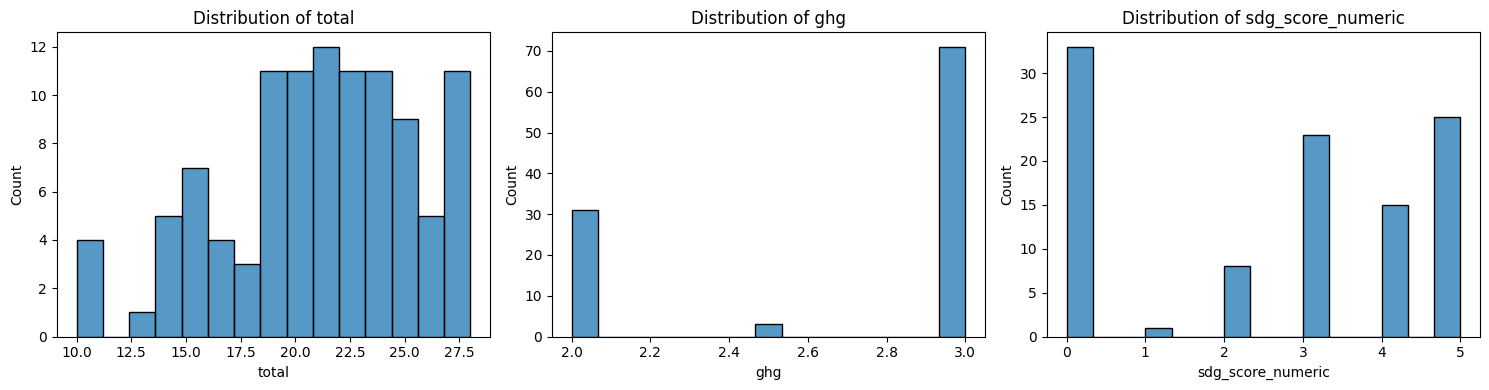

In [ ]:
#2. SG / GHG / SDG frequency
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['total', 'ghg', 'sdg_score_numeric']):
    sns.histplot(df[col].dropna(), bins=15, kde=False, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


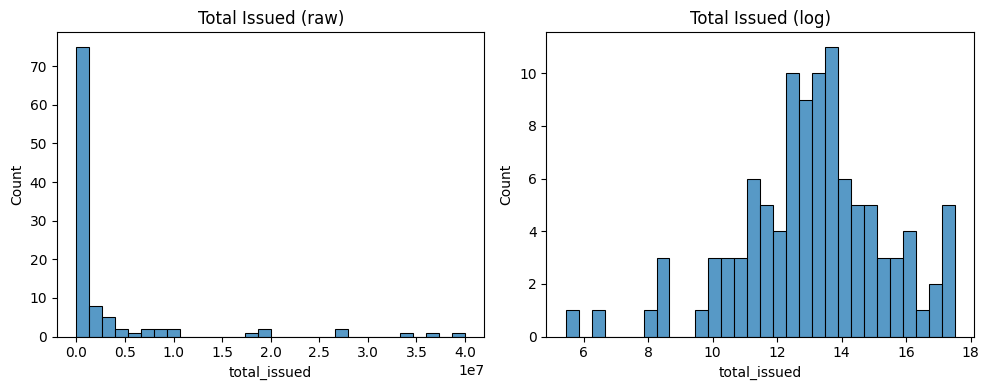

In [ ]:
#issuance size log frequency
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['total_issued'], bins=30, ax=axes[0])
axes[0].set_title('Total Issued (raw)')
sns.histplot(np.log1p(df['total_issued']), bins=30, ax=axes[1])
axes[1].set_title('Total Issued (log)')
plt.tight_layout()
plt.show()

In [ ]:
df['total_issued_LOG'] = np.log(df['total_issued'])

In [ ]:
# categorial variable frequency
df['weighted_vintage_year'] = df['weighted_vintage_date'].dt.year

for col in ['country', 'country_grouped', 'project_type', 'weighted_vintage_year']:
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = [col, 'count']
    freq_table['percentage'] = (freq_table['count'] / freq_table['count'].sum() * 100).round(2)
    print(f"\nFrequency table for {col}:")
    print(freq_table)


Frequency table for country:
             country  count  percentage
0           Colombia     14       13.33
1             Brazil     13       12.38
2              Kenya     11       10.48
3               Peru     10        9.52
4              China      9        8.57
5             Uganda      8        7.62
6              India      5        4.76
7            Uruguay      5        4.76
8           Paraguay      4        3.81
9           Cambodia      3        2.86
10          Tanzania      3        2.86
11         Indonesia      2        1.90
12         Guatemala      2        1.90
13             Ghana      2        1.90
14              Laos      2        1.90
15      Sierra Leone      2        1.90
16         Nicaragua      1        0.95
17            Mexico      1        0.95
18           Estonia      1        0.95
19          Ethiopia      1        0.95
20            Malawi      1        0.95
21     Guinea-Bissau      1        0.95
22            Panama      1        0.95
23        

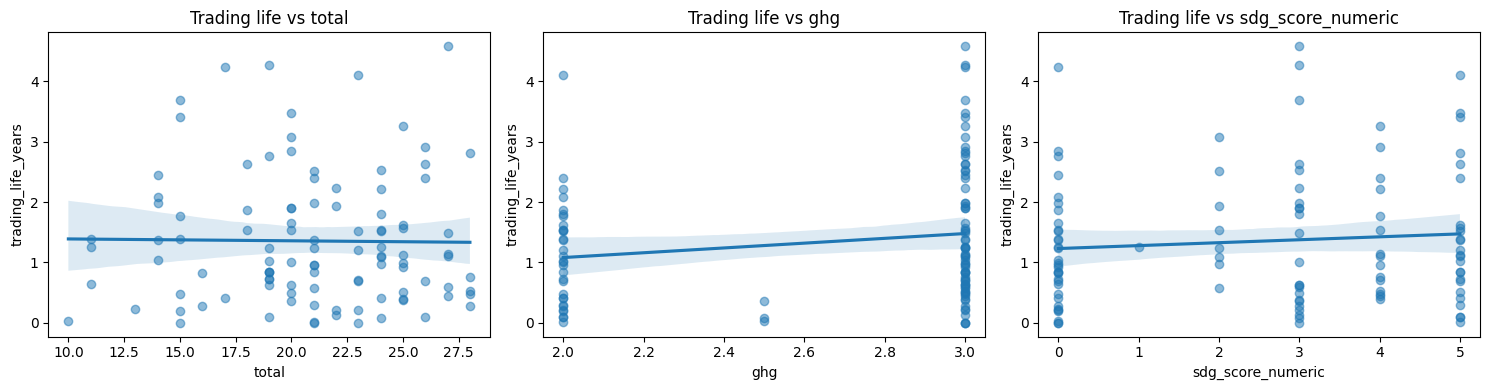

In [ ]:
#Trading life vs SG/GHG/SDG scatterplot + fitted
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['total', 'ghg', 'sdg_score_numeric']):
    sns.regplot(data=df, x=col, y='trading_life_years', ax=ax, scatter_kws={'alpha':0.5})
    ax.set_title(f'Trading life vs {col}')
plt.tight_layout()
plt.show()

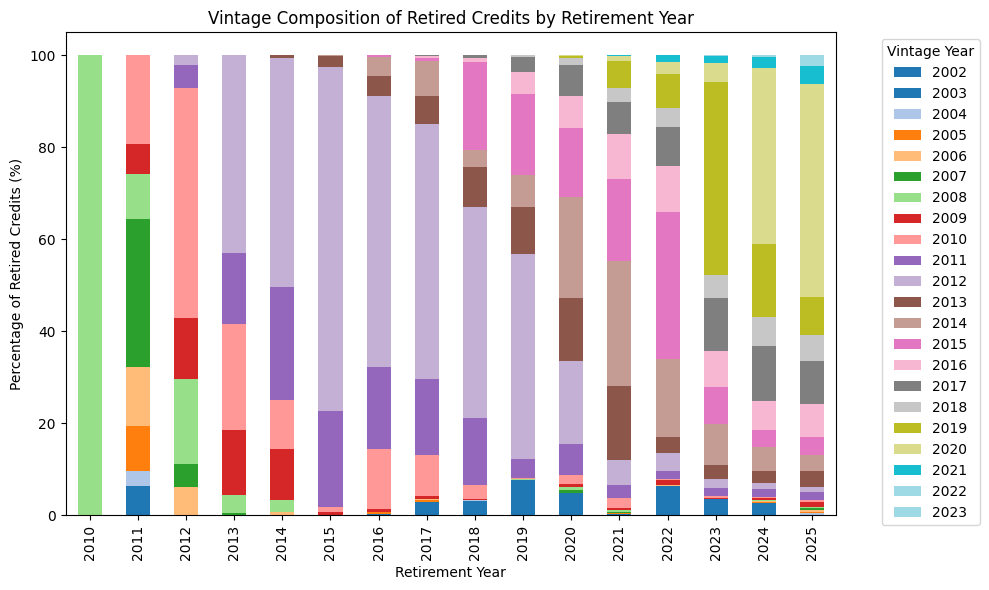

In [ ]:
# retirement rows
df_ret = df_trans_matched[df_trans_matched['transaction_type'] == 'retirement'].copy()

# retirement year
df_ret['retirement_year'] = pd.to_datetime(df_ret['transaction_date']).dt.year

# number of vintage year for each year's retirement
ret_vintage_counts = df_ret.groupby(['retirement_year', 'vintage']).size().reset_index(name='count')

# convert to percentage
ret_vintage_pivot = ret_vintage_counts.pivot(index='retirement_year', columns='vintage', values='count').fillna(0)
ret_vintage_pct = ret_vintage_pivot.div(ret_vintage_pivot.sum(axis=1), axis=0) * 100

# stacked bar chart
ret_vintage_pct.plot(kind='bar', stacked=True, figsize=(10,6), cmap='tab20')
plt.ylabel("Percentage of Retired Credits (%)")
plt.xlabel("Retirement Year")
plt.title("Vintage Composition of Retired Credits by Retirement Year")
plt.legend(title="Vintage Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

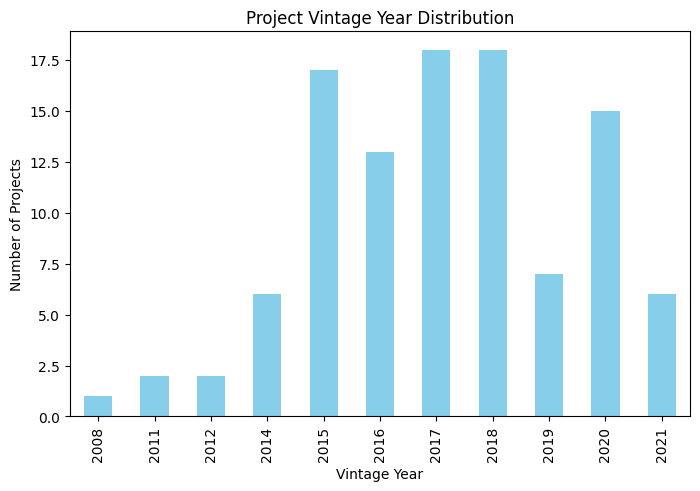

In [ ]:
plt.figure(figsize=(8,5))
df['vintage_year'] = pd.to_datetime(df['weighted_vintage_date']).dt.year
df['vintage_year'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.ylabel("Number of Projects")
plt.xlabel("Vintage Year")
plt.title("Project Vintage Year Distribution")
plt.show()

### VIF

In [ ]:

def compute_vif(df_features):
    # ensure float type
    df_num = df_features.apply(pd.to_numeric, errors='coerce')
    # drop missing value
    df_num = df_num.dropna()
    # add constant
    X = sm.add_constant(df_num)
    vif_df = pd.DataFrame({
        "variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    return vif_df.sort_values("VIF", ascending=False)

# ---- Characteristic Matrix with has_sdg_score ----
features_with_label = pd.concat([
    df[['total', 'ghg', 'sdg_score_numeric', 'has_sdg_score', 'total_issued_LOG']],
    pd.get_dummies(df[['country_grouped', 'project_type', 'weighted_vintage_year']], drop_first=True, dtype=float)
], axis=1)

print("\nVIF (with has_sdg_score):")
print(compute_vif(features_with_label))

# ---- Characteristic Matrix with only sdg_score_numeric ----
features_without_label = pd.concat([
    df[['total', 'ghg', 'sdg_score_numeric', 'total_issued_LOG']],
    pd.get_dummies(df[['country_grouped', 'project_type', 'weighted_vintage_year']], drop_first=True, dtype=float)
], axis=1)

print("\nVIF (without has_sdg_score):")
print(compute_vif(features_without_label))


VIF (含 has_sdg_score):
                    variable           VIF
0                      const  1.246649e+06
3          sdg_score_numeric  1.119201e+01
4              has_sdg_score  9.481682e+00
11     country_grouped_Kenya  3.730994e+00
18        project_type_REDD+  3.441634e+00
16    country_grouped_Uganda  3.131651e+00
12     country_grouped_Other  3.016991e+00
5           total_issued_LOG  2.260048e+00
8      country_grouped_China  2.207055e+00
2                        ghg  2.190850e+00
9   country_grouped_Colombia  2.184290e+00
1                      total  2.008578e+00
14      country_grouped_Peru  1.889081e+00
6      weighted_vintage_year  1.794630e+00
10     country_grouped_India  1.775695e+00
13  country_grouped_Paraguay  1.681474e+00
17   country_grouped_Uruguay  1.665741e+00
15  country_grouped_Tanzania  1.563854e+00
7   country_grouped_Cambodia  1.305640e+00

VIF (不含 has_sdg_score):
                    variable           VIF
0                      const  1.244468e+06
17   

In [ ]:
corr_matrix = df[['total', 'ghg', 'sdg_score_numeric']].corr(method='pearson')

print(corr_matrix)

                      total       ghg  sdg_score_numeric
total              1.000000  0.089012           0.504049
ghg                0.089012  1.000000          -0.203846
sdg_score_numeric  0.504049 -0.203846           1.000000


In [ ]:
corr_matrix = corr_matrix.rename(index={
    'total': 'Safeguard',
    'ghg': 'GHG Integrity',
    'sdg_score_numeric': 'SDG Co-benefit'
}, columns={
    'total': 'Safeguard',
    'ghg': 'GHG Integrity',
    'sdg_score_numeric': 'SDG Co-benefit'
})

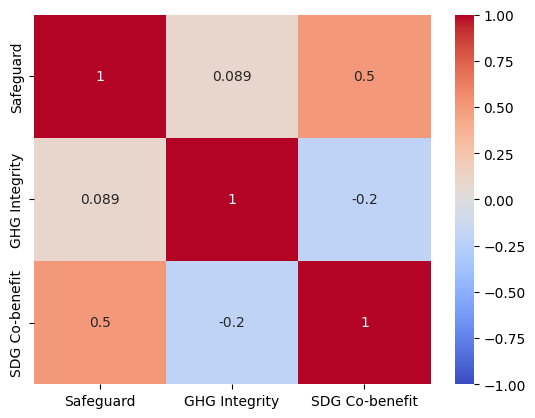

In [ ]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

## regression

In [ ]:
# 1. construct four dimensions
df['social'] = df[['gender', 'labor', 'iplc', 'cultural', 'hss']].sum(axis=1)
df['environmental'] = df[['biodiversity', 'resource', 'pollution']].sum(axis=1)
df['economic'] = df[['benefit', 'land']].sum(axis=1)
df['overall_governance'] = df[['assessment', 'stakeholder', 'mrv', 'grievance']].sum(axis=1)

# 2. variables need to standardize
vars_to_standardize = [
    'total', 'social', 'environmental', 'economic', 'overall_governance',
    'ghg', 'sdg_score_numeric'
]

# _z are standardized columns
scaler = StandardScaler()
df[[v + '_z' for v in vars_to_standardize]] = scaler.fit_transform(df[vars_to_standardize])

# 3. log transformation
vars_to_log = ['issuance_lag_years', 'retirement_age_years', 'trading_life_years']
for v in vars_to_log:
    df[v + '_log'] = np.log(df[v].replace(0, np.nan))

# check result
print(df[['social', 'environmental', 'economic', 'overall_governance']].head())
print(df[[v + '_z' for v in vars_to_standardize]].head())

   social  environmental  economic  overall_governance
0       2              1         4                   8
1       3              4         0                   8
2       1              2         2                   6
3       3              4         4                   8
4      10              5         3                   8
    total_z  social_z  environmental_z  economic_z  overall_governance_z  \
0 -1.365867 -1.520041        -2.647699    0.905246              0.522405   
1 -1.365867 -1.153976        -0.194684   -2.822238              0.522405   
2 -2.280802 -1.886105        -1.830027   -0.958496             -1.970890   
3 -0.450932 -1.153976        -0.194684    0.905246              0.522405   
4  1.150204  1.408478         0.622988   -0.026625              0.522405   

      ghg_z  sdg_score_numeric_z  
0 -1.519179            -1.313246  
1  0.681011             0.213221  
2  0.681011            -1.313246  
3  0.681011             0.213221  
4  0.681011             1.230865  


In [ ]:
desc_vars = ['total', 'social', 'environmental', 'economic', 'overall_governance', 'ghg', 'sdg_score_numeric']
desc_stats = df[desc_vars].agg(['mean', 'std', 'min', 'max', 'count']).T
desc_stats = desc_stats.rename(columns={'count': 'N'})
print("=== Descriptive statistics ===")
print(desc_stats)

=== Descriptive statistics ===
                         mean       std   min   max      N
total               20.971429  4.392864  10.0  28.0  105.0
social               6.152381  2.744859   0.0  10.0  105.0
environmental        4.238095  1.228850   1.0   6.0  105.0
economic             3.028571  1.078257   0.0   4.0  105.0
overall_governance   7.580952  0.805999   6.0   8.0  105.0
ghg                  2.690476  0.456686   2.0   3.0  105.0
sdg_score_numeric    2.580952  1.974749   0.0   5.0  105.0


In [ ]:
desc_vars_1 = ['total', 'gender', 'labor', 'iplc', 'cultural', 'hss', 'biodiversity', 'resource', 'pollution','benefit', 'land', 'assessment', 'stakeholder', 'mrv', 'grievance' ]
desc_stats_1 = df[desc_vars_1].agg(['mean', 'std', 'min', 'max', 'count']).T
desc_stats_1 = desc_stats_1.rename(columns={'count': 'N'})
print("=== Descriptive statistics ===")
print(desc_stats_1)

=== Descriptive statistics ===
                   mean       std   min   max      N
total         20.971429  4.392864  10.0  28.0  105.0
gender         1.247619  0.781775   0.0   2.0  105.0
labor          1.657143  0.704772   0.0   2.0  105.0
iplc           1.523810  0.773295   0.0   2.0  105.0
cultural       0.828571  0.859977   0.0   2.0  105.0
hss            0.895238  0.897902   0.0   2.0  105.0
biodiversity   1.914286  0.313611   0.0   2.0  105.0
resource       0.980952  0.771873   0.0   2.0  105.0
pollution      1.342857  0.830067   0.0   2.0  105.0
benefit        1.133333  0.951382   0.0   2.0  105.0
land           1.895238  0.414260   0.0   2.0  105.0
assessment     2.000000  0.000000   2.0   2.0  105.0
stakeholder    2.000000  0.000000   2.0   2.0  105.0
mrv            1.580952  0.805999   0.0   2.0  105.0
grievance      2.000000  0.000000   2.0   2.0  105.0


In [ ]:
controls = ['country_grouped', 'project_type', 'weighted_vintage_year', 'total_issued_LOG']
main_vars = ['social', 'environmental', 'economic', 'overall_governance', 'ghg', 'sdg_score_numeric']


# 3. drop missing value
X_raw = df[main_vars + controls].dropna()

# 4. Dummize
X_dummies = pd.get_dummies(X_raw, drop_first=True)

# 5. convert to float
X_dummies = X_dummies.astype(float)

# 6. add constant
X_final = sm.add_constant(X_dummies)

# 7. calc VIF
vif_df = pd.DataFrame()
vif_df["variable"] = X_final.columns
vif_df["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]

print(vif_df.sort_values("VIF", ascending=False).round(2))

                    variable         VIF
0                      const  1305004.49
6          sdg_score_numeric        3.75
20        project_type_REDD+        3.50
13     country_grouped_Kenya        3.35
18    country_grouped_Uganda        3.10
14     country_grouped_Other        2.81
1                     social        2.54
8           total_issued_LOG        2.38
5                        ghg        2.33
11  country_grouped_Colombia        2.28
10     country_grouped_China        2.23
4         overall_governance        1.99
16      country_grouped_Peru        1.98
7      weighted_vintage_year        1.87
3                   economic        1.82
2              environmental        1.75
19   country_grouped_Uruguay        1.73
12     country_grouped_India        1.67
15  country_grouped_Paraguay        1.56
17  country_grouped_Tanzania        1.55
9   country_grouped_Cambodia        1.31


In [ ]:
model0 = smf.ols(
    formula="trading_life_years ~ total",
    data=df
).fit(cov_type='HC3')

print(model0.summary())

                            OLS Regression Results                            
Dep. Variable:     trading_life_years   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.01570
Date:                Mon, 01 Sep 2025   Prob (F-statistic):              0.901
Time:                        22:51:07   Log-Likelihood:                -155.81
No. Observations:                 105   AIC:                             315.6
Df Residuals:                     103   BIC:                             320.9
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4194      0.530      2.679      0.0

In [ ]:
# Project level - main
# Model 1_org: total score
model1_org = smf.ols(
    formula="trading_life_years ~ total + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df
).fit(cov_type='HC3')

# Model 2_org: total -> 4 sub-dimensions
model2_org = smf.ols(
    formula="trading_life_years ~ social + environmental + economic + overall_governance + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df
).fit(cov_type='HC3')

print(model1_org.summary())
print(model2_org.summary())

                            OLS Regression Results                            
Dep. Variable:     trading_life_years   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     6.620
Date:                Fri, 15 Aug 2025   Prob (F-statistic):           3.79e-11
Time:                        01:38:22   Log-Likelihood:                -102.63
No. Observations:                 105   AIC:                             259.3
Df Residuals:                      78   BIC:                             330.9
Df Model:                          26                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:
# Project level - main
# Model 1_log: total score
model1_log = smf.ols(
    formula="trading_life_LOG_mean ~ total + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df
).fit(cov_type='HC3')

# Model 2_log: total -> 4 sub-dimensions
model2_log = smf.ols(
    formula="trading_life_LOG_mean ~ social + environmental + economic + overall_governance + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df
).fit(cov_type='HC3')

print(model1_log.summary())
print(model2_log.summary())


                              OLS Regression Results                             
Dep. Variable:     trading_life_LOG_mean   R-squared:                       0.424
Model:                               OLS   Adj. R-squared:                  0.232
Method:                    Least Squares   F-statistic:                     2.687
Date:                   Fri, 15 Aug 2025   Prob (F-statistic):           0.000424
Time:                           01:38:22   Log-Likelihood:                -260.49
No. Observations:                    105   AIC:                             575.0
Df Residuals:                         78   BIC:                             646.6
Df Model:                             26                                         
Covariance Type:                     HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

Robuestness check: reduce dimension

In [ ]:

df_work = df.copy()

# if total_issued_LOG does not exist，create log(1+x)
if 'total_issued_LOG' not in df_work.columns:
    df_work['total_issued_LOG'] = np.log1p(pd.to_numeric(df_work['total_issued'], errors='coerce'))

# ensure numerical (NaN if cannot be converted)
num_cols = [
    'total','ghg','sdg_score_numeric',
    'trading_life_years','retirement_age_LOG_mean','issuance_lag_LOG_mean',
    'total_issued_LOG',
    # four dimensions
    'social','environmental','economic','overall_governance'
]
for c in num_cols:
    if c in df_work.columns:
        df_work[c] = pd.to_numeric(df_work[c], errors='coerce')

# ========= 1) simply categories for countries =========
asia = {'India','Indonesia','China','Vietnam','Cambodia','Laos'}
africa = {'Kenya','Tanzania','Uganda','Zambia','Ghana'}
latam = {'Peru','Brazil','Colombia','Chile','Mexico'}

def grp_country(x):
    if x in asia: return 'Asia'
    if x in africa: return 'Africa'
    if x in latam: return 'Latin America'
    return 'Other'

if 'country_grouped_simplified' not in df_work.columns:
    df_work['country_grouped_simplified'] = df_work['country'].map(grp_country)

df_work['vintage_year'] = pd.to_numeric(df_work['weighted_vintage_year'], errors='coerce')

def grp_vintage(y):
    if pd.isna(y): return np.nan
    if y <= 2014: return '≤2014'
    if 2015 <= y <= 2018: return '2015–2018'
    if 2019 <= y <= 2021: return '2019–2021'
    return '≥2022'

if 'vintage_grouped' not in df_work.columns:
    df_work['vintage_grouped'] = df_work['vintage_year'].map(grp_vintage)

# ========= 2) Model 1: total: total value of SG  =========
# Y = trading_life_years；independent variables: total, ghg, sdg_score_numeric, total_issued_LOG + simplified FE
formula_m1 = """trading_life_years ~ total + ghg + sdg_score_numeric
                 + total_issued_LOG
                 + C(project_type) + C(country_grouped_simplified) + C(vintage_grouped)"""

# use patsy；NA_action='drop'
y1, X1 = dmatrices(formula_m1, data=df_work, return_type='dataframe', NA_action='drop')

# remove any +/-inf, just in case
mask1 = np.isfinite(y1.values.ravel()) & np.isfinite(X1.values).all(axis=1)
y1, X1 = y1.loc[mask1], X1.loc[mask1]

m1 = sm.OLS(y1, X1).fit(cov_type='HC3')
print(m1.summary())

# ========= 3) Model 2: total is split into four dimensions =========
need_dims = ['social','environmental','economic','overall_governance']
missing_dims = [c for c in need_dims if c not in df_work.columns]
if missing_dims:
    raise ValueError(f"there are no sub-dimensions {missing_dims}.")

formula_m2 = """trading_life_years ~ social + environmental + economic + overall_governance
                 + ghg + sdg_score_numeric
                 + total_issued_LOG
                 + C(project_type) + C(country_grouped_simplified) + C(vintage_grouped)"""

y2, X2 = dmatrices(formula_m2, data=df_work, return_type='dataframe', NA_action='drop')
mask2 = np.isfinite(y2.values.ravel()) & np.isfinite(X2.values).all(axis=1)
y2, X2 = y2.loc[mask2], X2.loc[mask2]

m2 = sm.OLS(y2, X2).fit(cov_type='HC3')
print(m2.summary())

# ========= 4) substitute Y：retirement_age / issuance_lag =========
# use patsy, only change the independent variables
for yvar in ['retirement_age_LOG_mean', 'issuance_lag_LOG_mean']:
    if yvar in df_work.columns:
        f_alt = formula_m1.replace('trading_life_years', yvar)
        ya, Xa = dmatrices(f_alt, data=df_work, return_type='dataframe', NA_action='drop')
        maskA = np.isfinite(ya.values.ravel()) & np.isfinite(Xa.values).all(axis=1)
        ya, Xa = ya.loc[maskA], Xa.loc[maskA]
        res = sm.OLS(ya, Xa).fit(cov_type='HC3')
        print(f"\n=== Alt Y: {yvar} ===")
        print(res.summary())

# ========= 5) Label-only sample(projects with real SDG) =========
df_label = df_work[df_work['sdg_score_numeric'] > 0].copy()
yl, Xl = dmatrices(formula_m1, data=df_label, return_type='dataframe', NA_action='drop')
maskL = np.isfinite(yl.values.ravel()) & np.isfinite(Xl.values).all(axis=1)
yl, Xl = yl.loc[maskL], Xl.loc[maskL]
m_label = sm.OLS(yl, Xl).fit(cov_type='HC3')
print("\n=== Label-only sample (Model 1) ===")
print(m_label.summary())

                            OLS Regression Results                            
Dep. Variable:     trading_life_years   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     5.977
Date:                Fri, 15 Aug 2025   Prob (F-statistic):           5.87e-07
Time:                        01:38:22   Log-Likelihood:                -123.95
No. Observations:                 105   AIC:                             269.9
Df Residuals:                      94   BIC:                             299.1
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [ ]:
#Alternative dependent variables
# Retirement lag
alt1 = smf.ols(
    formula="retirement_age_LOG_mean ~ total + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df
).fit(cov_type='HC3')


alt2 = smf.ols(
    formula="issuance_lag_LOG_mean ~ total + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df
).fit(cov_type='HC3')
print(alt1.summary())
print(alt2.summary())

                               OLS Regression Results                              
Dep. Variable:     retirement_age_LOG_mean   R-squared:                       0.520
Model:                                 OLS   Adj. R-squared:                  0.360
Method:                      Least Squares   F-statistic:                     5.911
Date:                     Fri, 15 Aug 2025   Prob (F-statistic):           4.93e-10
Time:                             01:38:23   Log-Likelihood:                -28.579
No. Observations:                      105   AIC:                             111.2
Df Residuals:                           78   BIC:                             182.8
Df Model:                               26                                         
Covariance Type:                       HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

In [ ]:
proj_vars = [
    'project_id',
    'total',
    'ghg',
    'sdg_score_numeric',
    'project_type',
    'total_issued_LOG',
    'country_grouped',
    'social',
    'environmental',
    'economic',
    'overall_governance'

]

proj_df = df[proj_vars].drop_duplicates()

# merge to transaction level: df_trans_matched
df_trans_matched = df_trans_matched.merge(proj_df, on='project_id', how='left')

In [ ]:
df_trans_matched.head()

,project_id,quantity,retirement_account,retirement_beneficiary,retirement_beneficiary_harmonized,retirement_note,retirement_reason,transaction_date,transaction_type,vintage,...,total,ghg,sdg_score_numeric,project_type,total_issued_LOG,country_grouped,social,environmental,economic,overall_governance
0,VCS1015,2648,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2008,...,15,2.0,0.0,Afforestation + Reforestation,11.264503,India,2,1,4,8
1,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2009,...,15,2.0,0.0,Afforestation + Reforestation,11.264503,India,2,1,4,8
2,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2010,...,15,2.0,0.0,Afforestation + Reforestation,11.264503,India,2,1,4,8
3,VCS1015,5685,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2011,...,15,2.0,0.0,Afforestation + Reforestation,11.264503,India,2,1,4,8
4,VCS1015,5701,NaN,NaN,NaN,NaN,NaN,2023-06-28,issuance,2012,...,15,2.0,0.0,Afforestation + Reforestation,11.264503,India,2,1,4,8


In [ ]:
df_trans_matched.columns

Index(['project_id', 'quantity', 'retirement_account',
       'retirement_beneficiary', 'retirement_beneficiary_harmonized',
       'retirement_note', 'retirement_reason', 'transaction_date',
       'transaction_type', 'vintage', 'country', 'vintage_date', 'delay_years',
       'issuance_lag_years', 'retirement_age_years',
       'issuance_date_for_vintage', 'trading_life_years', 'issuance_lag_LOG',
       'retirement_age_LOG', 'trading_life_LOG', 'total', 'ghg',
       'sdg_score_numeric', 'project_type', 'total_issued_LOG',
       'country_grouped', 'social', 'environmental', 'economic',
       'overall_governance'],
      dtype='object')

In [ ]:
#TRANSACTION LEVEL
df_ret = df_trans_matched[df_trans_matched['transaction_type'] == 'retirement'].copy()
# Trading life: retirement rows only
tx3 = smf.wls(
    formula="trading_life_years ~ total + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(vintage) + total_issued_LOG",
    data=df_ret,
    weights=df_ret['quantity']
).fit(cov_type='HC3')

tx4 = smf.wls(
    formula="trading_life_years ~ social + environmental + economic + overall_governance + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(vintage) + total_issued_LOG",
    data=df_ret,
    weights=df_ret['quantity']
).fit(cov_type='HC3')


print(tx3.summary())
print(tx4.summary())



/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:806: RuntimeWarning: divide by zero encountered in log
  llf += 0.5 * np.sum(np.log(self.weights))
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:806: RuntimeWarning: divide by zero encountered in log
  llf += 0.5 * np.sum(np.log(self.weights))


                            WLS Regression Results                            
Dep. Variable:     trading_life_years   R-squared:                       0.361
Model:                            WLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     27.66
Date:                Fri, 15 Aug 2025   Prob (F-statistic):          2.27e-189
Time:                        01:38:32   Log-Likelihood:                   -inf
No. Observations:               77408   AIC:                               inf
Df Residuals:                   77370   BIC:                               inf
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [ ]:
#TRANSACTION LEVEL
df_ret = df_trans_matched[df_trans_matched['transaction_type'] == 'retirement'].copy()
# Trading life: retirement rows only
tx3_log = smf.wls(
    formula="trading_life_LOG ~ total + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(vintage) + total_issued_LOG",
    data=df_ret,
    weights=df_ret['quantity']
).fit(cov_type='HC3')

tx4_log = smf.wls(
    formula="trading_life_LOG ~ social + environmental + economic + overall_governance + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(vintage) + total_issued_LOG",
    data=df_ret,
    weights=df_ret['quantity']
).fit(cov_type='HC3')


print(tx3_log.summary())
print(tx4_log.summary())

                            WLS Regression Results                            
Dep. Variable:       trading_life_LOG   R-squared:                       0.184
Model:                            WLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     11.15
Date:                Fri, 15 Aug 2025   Prob (F-statistic):           9.83e-65
Time:                        01:55:56   Log-Likelihood:                   -inf
No. Observations:               77408   AIC:                               inf
Df Residuals:                   77370   BIC:                               inf
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:806: RuntimeWarning: divide by zero encountered in log
  llf += 0.5 * np.sum(np.log(self.weights))
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:806: RuntimeWarning: divide by zero encountered in log
  llf += 0.5 * np.sum(np.log(self.weights))


In [ ]:
df_label = df[df['sdg_score_numeric'] != 0].copy()

label_model = smf.ols(
    formula="trading_life_years ~ total + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df_label
).fit(cov_type='HC3')

label_model_4 = smf.ols(
    formula="trading_life_years ~ social + environmental + economic + overall_governance + ghg + sdg_score_numeric + C(country_grouped) + C(project_type) + C(weighted_vintage_year) + total_issued_LOG",
    data=df_label
).fit(cov_type='HC3')

print(label_model.summary())
print(label_model_4.summary())

                            OLS Regression Results                            
Dep. Variable:     trading_life_years   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     3.837
Date:                Fri, 15 Aug 2025   Prob (F-statistic):           4.02e-05
Time:                        01:55:06   Log-Likelihood:                -67.395
No. Observations:                  72   AIC:                             184.8
Df Residuals:                      47   BIC:                             241.7
Df Model:                          24                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 26, but rank is 24
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 29, but rank is 27
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# ========= 1) take sub-sample with label =========
df_label = df_work[df_work['sdg_score_numeric'] != 0].copy()

# ========= 2) variable type check =========
# numerical columns
num_cols = [
    'total','ghg','sdg_score_numeric',
    'total_issued_LOG','social','environmental','economic','overall_governance'
]
for c in num_cols:
    df_label[c] = pd.to_numeric(df_label[c], errors='coerce')

# categoric columns
df_label['country_grouped_simplified'] = df_label['country_grouped_simplified'].astype('category')
df_label['vintage_grouped'] = df_label['vintage_grouped'].astype('category')
df_label['project_type'] = df_label['project_type'].astype('category')

# ========= 3) VIF check）=========
X = df_label[['social', 'environmental', 'economic', 'overall_governance',
              'ghg', 'sdg_score_numeric', 'total_issued_LOG']].copy()

# add dummy(country, year, type)
X = pd.get_dummies(
    pd.concat([X, df_label[['country_grouped_simplified',
                            'vintage_grouped',
                            'project_type']]],
              axis=1),
    drop_first=True
)

X = sm.add_constant(X)

X = X.dropna()

# make sure the matirx is float64
X = X.astype(float)

vif_data = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data.sort_values("VIF", ascending=False))


# ========= 4) regression(use 'total'))=========
model_total = smf.ols(
    formula="trading_life_years ~ total + ghg + sdg_score_numeric + C(country_grouped_simplified) + C(project_type) + C(vintage_grouped) + total_issued_LOG",
    data=df_label
).fit(cov_type='HC3')

# ========= 5) regression (four dimension)=========
model_dims = smf.ols(
    formula="trading_life_years ~ social + environmental + economic + overall_governance + ghg + sdg_score_numeric + C(country_grouped_simplified) + C(project_type) + C(vintage_grouped) + total_issued_LOG",
    data=df_label
).fit(cov_type='HC3')

print(model_total.summary())
print(model_dims.summary())

                                    variable          VIF
0                                      const  1066.973738
9   country_grouped_simplified_Latin America     4.867091
13                        project_type_REDD+     3.845015
6                          sdg_score_numeric     2.810938
7                           total_issued_LOG     2.394038
8            country_grouped_simplified_Asia     2.344676
5                                        ghg     2.161549
1                                     social     1.869703
10          country_grouped_simplified_Other     1.669283
2                              environmental     1.463814
3                                   economic     1.406866
11                 vintage_grouped_2019–2021     1.287690
4                         overall_governance     1.283770
12                     vintage_grouped_≤2014     1.207431
                            OLS Regression Results                            
Dep. Variable:     trading_life_years   R-squared: 